In [1]:
organism_file = "organism.csv"
anchor_file = "anchor.csv"
globi_file = "globi.csv"
habitat_file = "habitat.csv"
inhabit_file = "inhabit.csv"

In [2]:
import pandas as pd
data_df = pd.read_csv("test_data.csv")
data_df

,id,name,label,url,scientific_name
0,data_2154,Adelie penguin specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/2154,Adelie penguin
1,data_874,Antarctic krill specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/874,Antarctic krill
2,data_1852,long-tailed duck specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/1852,Long-tailed Duck
3,data_3186,fairy shrimp specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/3186,Anostraca
4,data_396,Adelie penguin specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/396,Adelie penguin
5,data_3115,king penguin specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/3115,King Penguin
6,data_814,sea spiders specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/814,Pycnogonida
7,data_213,crustaceans specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/213,Crustaceans
8,data_3033,Serolis specimen,BiologicalSpecimen,https://amider.rois.ac.jp/data/3033,Serolis


In [3]:
import requests
import xml.etree.ElementTree as ET

NCBI_ESEARCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
NCBI_EFETCH  = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"


def get_ncbi_taxonomy(scientific_name: str):
    """
    Input:
        scientific_name (str)

    Output:
        dict or None
    """

    print(f"\nSearching NCBI taxonomy: {scientific_name}")

    # -------------------------
    # Step 1: Search TaxID
    # -------------------------
    params = {
        "db": "taxonomy",
        "term": scientific_name,
        "retmode": "json"
    }

    r = requests.get(NCBI_ESEARCH, params=params, timeout=30)
    r.raise_for_status()

    id_list = (
        r.json()
        .get("esearchresult", {})
        .get("idlist", [])
    )

    print(f"Search returned {len(id_list)} candidate(s)")

    if not id_list:
        print("No match found")
        return None

    tax_id = id_list[0]

    print(f"Using TaxID: {tax_id}")

    # -------------------------
    # Step 2: Fetch Taxonomy
    # -------------------------
    params = {
        "db": "taxonomy",
        "id": tax_id,
        "retmode": "xml"
    }

    r = requests.get(NCBI_EFETCH, params=params, timeout=30)
    r.raise_for_status()

    root = ET.fromstring(r.text)

    taxon = root.find(".//Taxon")
    if taxon is None:
        print("Failed to fetch taxonomy record")
        return None

    def get_text(tag):
        e = taxon.find(tag)
        return e.text.strip() if e is not None and e.text else None

    common_name = get_text("CommonName")

    other = taxon.find("OtherNames")
    if other is not None:
        for tag in ["GenbankCommonName", "CommonName"]:
            e = other.find(tag)
            if e is not None and e.text:
                common_name = e.text.strip()
                break

    result = {
        "id": f"organism_{tax_id}",
        "tax_id": get_text("TaxId"),
        "scientific_name": get_text("ScientificName"),
        "common_name": common_name,
        "rank": get_text("Rank"),
        "url": f"https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/wwwtax.cgi?id={tax_id}"
    }

    print(
        f"Retrieved: "
        f"{result['scientific_name']} "
        f"(rank={result['rank']}, tax_id={result['tax_id']})"
    )

    return result

In [4]:
from pathlib import Path
import pandas as pd


def append2csvfile(row, file_path):
    file_path = Path(file_path)

    print(f"\nTarget file: {file_path}")

    if not file_path.exists():
        print("File does not exist. Creating new CSV...")

        df = pd.DataFrame([row])
        print(f"Columns: {list(df.columns)}")
        print("Writing first row")

        df.to_csv(file_path, index=False)

        print(f"CSV created: {file_path}")
        return

    print("Reading existing CSV...")
    df = pd.read_csv(file_path)

    print(f"Current rows: {len(df)}")
    print(f"Columns: {list(df.columns)}")

    existing_cols = list(df.columns)
    row_cols = list(row.keys())

    print(f"Incoming row keys: {row_cols}")

    if set(existing_cols) != set(row_cols):
        print("Column mismatch detected.")

        missing = set(existing_cols) - set(row_cols)
        extra = set(row_cols) - set(existing_cols)

        if missing:
            print(f"Missing keys: {sorted(missing)}")

        if extra:
            print(f"Extra keys: {sorted(extra)}")

        raise ValueError(
            f"Column mismatch.\n"
            f"CSV columns : {existing_cols}\n"
            f"Row keys    : {row_cols}"
        )

    print("Column check passed.")

    new_row = {col: row[col] for col in existing_cols}

    # Check duplicate: all columns are exactly the same
    duplicate_mask = (
        df.astype(str)
        == pd.Series(new_row).astype(str)
    ).all(axis=1)

    if duplicate_mask.any():
        print("Duplicate row detected. Skipping append.")
        return

    print("No duplicate row found.")
    print("Appending row...")

    df = pd.concat(
        [df, pd.DataFrame([new_row])],
        ignore_index=True,
    )

    print(f"New row count: {len(df)}")

    print("Saving CSV...")
    df.to_csv(file_path, index=False)

    print(f"Successfully appended to {file_path}")

In [5]:
from pathlib import Path
from urllib.parse import quote
import re
import time
import requests
import pandas as pd


GLOBI_API_URL = "https://api.globalbioticinteractions.org/interaction"

GLOBI_INTERACTION_COLUMNS = [
    "coOccursWith",
    "eatenBy",
    "eats",
    "hasHost",
    "hasParasite",
    "hasPathogen",
    "hasVector",
    "hostOf",
    "interactsWith",
    "killedBy",
    "kills",
    "parasiteOf",
    "pathogenOf",
    "preyedUponBy",
    "preysOn",
    "symbiontOf",
    "vectorOf",
]




def camel_to_upper_snake(name):
    """
    Example:
        preysOn -> PREYS_ON
        preyedUponBy -> PREYED_UPON_BY
        coOccursWith -> CO_OCCURS_WITH
    """
    return re.sub(r"(?<!^)(?=[A-Z])", "_", name).upper()


def build_globi_interaction_url(source_name, interaction_type, target_name):
    return (
        "https://www.globalbioticinteractions.org/?"
        f"sourceTaxon={quote(source_name)}&"
        f"interactionType={quote(interaction_type)}&"
        f"targetTaxon={quote(target_name)}"
    )


def normalize_tax_id(value):
    if pd.isna(value):
        return None

    text = str(value).strip()

    if not text or text.lower() == "unknown":
        return None

    try:
        return str(int(float(text)))
    except ValueError:
        return None


def extract_ncbi_taxid(external_id):
    if not isinstance(external_id, str):
        return None

    if not external_id.startswith("NCBI:"):
        return None

    return normalize_tax_id(external_id.split(":", 1)[1])


def load_existing_globi_keys(globi_file):
    """
    Load existing relations from globi_file for duplicate checking.

    Duplicate key:
        from_id, to_id, relation_type
    """

    globi_file = Path(globi_file)

    if not globi_file.exists():
        print(f"GloBI file does not exist yet: {globi_file}")
        return set()

    df = pd.read_csv(globi_file)

    required_cols = {"from_id", "to_id", "relation_type"}
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise ValueError(
            f"Missing required columns in existing globi_file: {sorted(missing_cols)}"
        )

    keys = set(
        zip(
            df["from_id"].astype(str),
            df["to_id"].astype(str),
            df["relation_type"].astype(str),
        )
    )

    print(f"Loaded existing GloBI relations: {len(keys)}")

    return keys


def build_globi_relations(
    organism_file,
    globi_file,
    rate_limit=0.4,
):
    """
    Build GloBI relations among organisms listed in organism_file.

    Input organism_file columns:
        id, tax_id, scientific_name, common_name, rank, url

    Output globi_file columns:
        from_id, to_id, relation_type, url

    Notes:
        - Search GloBI by scientific_name.
        - Only keep target organisms already included in organism_file.
        - Do not infer reverse relations.
        - Append to existing globi_file.
        - Avoid duplicate rows using from_id, to_id, relation_type.
    """

    organism_file = Path(organism_file)
    globi_file = Path(globi_file)

    print(f"Reading organism file: {organism_file}")

    organism_df = pd.read_csv(organism_file)

    required_cols = {"id", "tax_id", "scientific_name"}
    missing_cols = required_cols - set(organism_df.columns)

    if missing_cols:
        raise ValueError(
            f"Missing required columns in organism_file: {sorted(missing_cols)}"
        )

    print(f"Organism rows: {len(organism_df)}")

    organism_df["tax_id_normalized"] = organism_df["tax_id"].map(normalize_tax_id)

    organism_df = organism_df.dropna(subset=["tax_id_normalized"])

    taxid_to_node_id = dict(
        zip(
            organism_df["tax_id_normalized"],
            organism_df["id"],
        )
    )

    taxid_to_name = dict(
        zip(
            organism_df["tax_id_normalized"],
            organism_df["scientific_name"],
        )
    )

    valid_taxids = set(taxid_to_node_id.keys())

    print(f"Valid NCBI TaxIDs in organism file: {len(valid_taxids)}")

    existing_keys = load_existing_globi_keys(globi_file)

    fields = [
        "target_taxon_external_id",
        "interaction_type",
    ]

    added_total = 0
    skipped_duplicates = 0
    errors = []

    with requests.Session() as session:
        for i, row in organism_df.iterrows():
            source_id = str(row["id"])
            source_name = row["scientific_name"]

            if not isinstance(source_name, str) or not source_name.strip():
                print(f"Skipping row {i}: empty scientific_name")
                continue

            if source_name.strip().lower() == "unknown":
                print(f"Skipping row {i}: scientific_name is unknown")
                continue

            source_name = source_name.strip()

            print(f"\nSearching GloBI: {source_name}")

            params = {
                "sourceTaxon": source_name,
                "fields": ",".join(fields),
            }

            try:
                response = session.get(
                    GLOBI_API_URL,
                    params=params,
                    timeout=30,
                )
                response.raise_for_status()
                payload = response.json()

            except Exception as exc:
                print(f"GloBI API error for {source_name}: {exc}")
                errors.append(
                    {
                        "source_id": source_id,
                        "scientific_name": source_name,
                        "error": str(exc),
                    }
                )
                continue

            columns = payload.get("columns", [])
            data = payload.get("data", [])

            print(f"Returned records: {len(data)}")

            added_for_source = 0

            for record in data:
                if len(record) != len(columns):
                    continue

                rec = dict(zip(columns, record))

                interaction_type = rec.get("interaction_type")

                if interaction_type not in GLOBI_INTERACTION_COLUMNS:
                    continue

                target_taxid = extract_ncbi_taxid(
                    rec.get("target_taxon_external_id")
                )

                if target_taxid is None:
                    continue

                if target_taxid not in valid_taxids:
                    continue

                target_id = str(taxid_to_node_id[target_taxid])
                target_name = str(taxid_to_name[target_taxid]).strip()

                if not target_name or target_name.lower() == "unknown":
                    continue

                relation_type = camel_to_upper_snake(interaction_type)

                key = (
                    source_id,
                    target_id,
                    relation_type,
                )

                if key in existing_keys:
                    skipped_duplicates += 1
                    continue

                relation_url = build_globi_interaction_url(
                    source_name=source_name,
                    interaction_type=interaction_type,
                    target_name=target_name,
                )

                relation_row = {
                    "from_id": source_id,
                    "to_id": target_id,
                    "relation_type": relation_type,
                    "url": relation_url,
                }

                append2csvfile(
                    row=relation_row,
                    file_path=globi_file,
                )

                existing_keys.add(key)

                added_total += 1
                added_for_source += 1

            print(f"Added relations for this source: {added_for_source}")

            time.sleep(rate_limit)

    print("\nFinished.")
    print(f"Total added relations: {added_total}")
    print(f"Skipped duplicate relations: {skipped_duplicates}")
    print(f"GloBI API errors: {len(errors)}")

    if errors:
        print("Errors:")
        for err in errors:
            print(err)

In [6]:
import pandas as pd

HabitatType_df = pd.DataFrame([
    {
        "id": "habitattype_marine",
        "name": "marine",
    },
    {
        "id": "habitattype_brackish",
        "name": "brackish",
    },
    {
        "id": "habitattype_freshwater",
        "name": "freshwater",
    },
    {
        "id": "habitattype_terrestrial",
        "name": "terrestrial",
    },
])

HabitatType_df.to_csv(habitat_file, index=False)

In [7]:
from pathlib import Path
from urllib.parse import quote
import time
import requests
import pandas as pd


WORMS_API_BASE_URL = "https://www.marinespecies.org/rest/AphiaRecordsByName"

WORMS_HABITAT_COLUMNS = {
    "isMarine": "Marine",
    "isBrackish": "Brackish",
    "isFreshwater": "Freshwater",
    "isTerrestrial": "Terrestrial",
}

def worms_flag_is_positive(value):
    if pd.isna(value):
        return False

    return str(value).strip().lower() in {"1", "true"}


def build_worms_record_url(record):
    record_url = record.get("url")

    if isinstance(record_url, str) and record_url.strip():
        return record_url.strip()

    aphia_id = record.get("AphiaID")

    if pd.isna(aphia_id):
        return ""

    aphia_text = str(aphia_id).strip()

    if not aphia_text:
        return ""

    return f"https://www.marinespecies.org/aphia.php?p=taxdetails&id={aphia_text}"


def load_existing_relation_keys(relation_file):
    """
    Load existing relation keys from a CSV file.

    Duplicate key:
        from_id, to_id, relation_type
    """

    relation_file = Path(relation_file)

    if not relation_file.exists():
        print(f"Relation file does not exist yet: {relation_file}")
        return set()

    df = pd.read_csv(relation_file)

    required_cols = {"from_id", "to_id", "relation_type"}
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise ValueError(
            f"Missing required columns in existing relation file: {sorted(missing_cols)}"
        )

    keys = set(
        zip(
            df["from_id"].astype(str),
            df["to_id"].astype(str),
            df["relation_type"].astype(str),
        )
    )

    print(f"Loaded existing relations: {len(keys)}")

    return keys


def build_habitat_name_to_id(habitat_file):
    """
    Build a lookup dictionary from habitat name to habitat node id.

    Expected habitat_file columns:
        id, name

    The habitat names should include:
        Marine
        Brackish
        Freshwater
        Terrestrial
    """

    habitat_file = Path(habitat_file)

    print(f"Reading habitat file: {habitat_file}")

    habitat_df = pd.read_csv(habitat_file)

    required_cols = {"id", "name"}
    missing_cols = required_cols - set(habitat_df.columns)

    if missing_cols:
        raise ValueError(
            f"Missing required columns in habitat_file: {sorted(missing_cols)}"
        )

    habitat_name_to_id = {}

    for _, row in habitat_df.iterrows():
        habitat_id = str(row["id"]).strip()
        habitat_name = str(row["name"]).strip()

        if habitat_id and habitat_name:
            habitat_name_to_id[habitat_name.lower()] = habitat_id

    print(f"Habitat nodes loaded: {len(habitat_name_to_id)}")

    return habitat_name_to_id


def build_worms_inhabits_relations(
    organism_file,
    habitat_file,
    inhabit_file,
    relation_type="INHABITS",
    rate_limit=0.2,
):
    """
    Build organism-habitat relations using WoRMS.

    Input organism_file columns:
        id, tax_id, scientific_name, common_name, rank, url

    Input habitat_file columns:
        id, name

    Output inhabit_file columns:
        from_id, to_id, relation_type, url

    Notes:
        - Search WoRMS by organism scientific_name.
        - Use WoRMS habitat flags:
            isMarine
            isBrackish
            isFreshwater
            isTerrestrial
        - Only keep habitats that exist in habitat_file.
        - Append to existing inhabit_file.
        - Avoid duplicate rows using from_id, to_id, relation_type.
    """

    organism_file = Path(organism_file)
    habitat_file = Path(habitat_file)
    inhabit_file = Path(inhabit_file)

    print(f"Reading organism file: {organism_file}")

    organism_df = pd.read_csv(organism_file)

    required_cols = {"id", "scientific_name"}
    missing_cols = required_cols - set(organism_df.columns)

    if missing_cols:
        raise ValueError(
            f"Missing required columns in organism_file: {sorted(missing_cols)}"
        )

    print(f"Organism rows: {len(organism_df)}")

    habitat_name_to_id = build_habitat_name_to_id(habitat_file)

    existing_keys = load_existing_relation_keys(inhabit_file)

    added_total = 0
    skipped_duplicates = 0
    skipped_missing_habitat = 0
    errors = []

    with requests.Session() as session:
        for i, row in organism_df.iterrows():
            source_id = str(row["id"]).strip()
            source_name = row["scientific_name"]

            if not source_id:
                print(f"Skipping row {i}: empty organism id")
                continue

            if not isinstance(source_name, str) or not source_name.strip():
                print(f"Skipping row {i}: empty scientific_name")
                continue

            if source_name.strip().lower() == "unknown":
                print(f"Skipping row {i}: scientific_name is unknown")
                continue

            source_name = source_name.strip()

            print(f"\nSearching WoRMS: {source_name}")

            try:
                response = session.get(
                    f"{WORMS_API_BASE_URL}/{quote(source_name)}",
                    params={
                        "like": "false",
                        "marine_only": "false",
                    },
                    timeout=30,
                )
                response.raise_for_status()
                records = response.json()

            except Exception as exc:
                print(f"WoRMS API error for {source_name}: {exc}")
                errors.append(
                    {
                        "source_id": source_id,
                        "scientific_name": source_name,
                        "error": str(exc),
                    }
                )
                time.sleep(rate_limit)
                continue

            if not isinstance(records, list) or not records:
                print("No WoRMS record found")
                time.sleep(rate_limit)
                continue

            record = records[0]
            record_url = build_worms_record_url(record)

            added_for_source = 0

            for api_field, habitat_name in WORMS_HABITAT_COLUMNS.items():
                if not worms_flag_is_positive(record.get(api_field)):
                    continue

                habitat_id = habitat_name_to_id.get(habitat_name.lower())

                if habitat_id is None:
                    print(f"Habitat not found in habitat_file: {habitat_name}")
                    skipped_missing_habitat += 1
                    continue

                key = (
                    source_id,
                    habitat_id,
                    relation_type,
                )

                if key in existing_keys:
                    skipped_duplicates += 1
                    continue

                relation_row = {
                    "from_id": source_id,
                    "to_id": habitat_id,
                    "relation_type": relation_type,
                    "url": record_url,
                }

                append2csvfile(
                    row=relation_row,
                    file_path=inhabit_file,
                )

                existing_keys.add(key)

                added_total += 1
                added_for_source += 1

            print(f"Added INHABITS relations for this source: {added_for_source}")

            time.sleep(rate_limit)

    print("\nFinished.")
    print(f"Total added relations: {added_total}")
    print(f"Skipped duplicate relations: {skipped_duplicates}")
    print(f"Skipped missing habitats: {skipped_missing_habitat}")
    print(f"WoRMS API errors: {len(errors)}")

    if errors:
        print("Errors:")
        for err in errors:
            print(err)

In [8]:
import time
for i,row in data_df.iterrows():
    ncbi = get_ncbi_taxonomy(row["scientific_name"])
    anchor = {"from_id": row["id"], "to_id": ncbi["id"], "relation_type":"SPECIMEN_OF_ORGANISM"}
    print(ncbi)
    time.sleep(5)
    append2csvfile(ncbi, organism_file)
    append2csvfile(anchor, anchor_file)
    globi_df = build_globi_relations(
        organism_file=organism_file,
        globi_file=globi_file,
    )
    build_worms_inhabits_relations(
        organism_file=organism_file,
        habitat_file=habitat_file,
        inhabit_file=inhabit_file,
    )


Searching NCBI taxonomy: Adelie penguin
Search returned 1 candidate(s)
Using TaxID: 9238
Retrieved: Pygoscelis adeliae (rank=species, tax_id=9238)
{'id': 'organism_9238', 'tax_id': '9238', 'scientific_name': 'Pygoscelis adeliae', 'common_name': 'Adelie penguin', 'rank': 'species', 'url': 'https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/wwwtax.cgi?id=9238'}

Target file: organism.csv
Reading existing CSV...
Current rows: 1
Columns: ['id', 'tax_id', 'scientific_name', 'common_name', 'rank', 'url']
Incoming row keys: ['id', 'tax_id', 'scientific_name', 'common_name', 'rank', 'url']
Column check passed.
Duplicate row detected. Skipping append.

Target file: anchor.csv
Reading existing CSV...
Current rows: 1
Columns: ['from_id', 'to_id', 'relation_type']
Incoming row keys: ['from_id', 'to_id', 'relation_type']
Column check passed.
Duplicate row detected. Skipping append.
Reading organism file: organism.csv
Organism rows: 1
Valid NCBI TaxIDs in organism file: 1
GloBI file does not exist yet: 

In [2]:
from py2neo import Graph,Node,Relationship

graph = Graph("bolt://localhost:7687", auth=("neo4j", "macbook12345"))

In [23]:

print(graph.run("RETURN 1 AS ok").data())
confirm = input("⚠️  This will DELETE ALL nodes and relationships in the database. Type 'yes' to continue: ")

if confirm.strip().lower() == "yes":
    graph.run("MATCH (n) DETACH DELETE n")
    print("✅ Database cleared.")
else:
    print("❌ Operation cancelled.")


[{'ok': 1}]


⚠️  This will DELETE ALL nodes and relationships in the database. Type 'yes' to continue:  yes


✅ Database cleared.


In [24]:
from py2neo import Relationship


def create_edge(
    graph,
    from_id,
    to_id,
    relation_type,
    **properties
):
    """
    Create a relationship between two existing nodes.

    Parameters
    ----------
    graph : py2neo.Graph

    from_id : str
        Source node id

    to_id : str
        Target node id

    relation_type : str
        Example:
            PREYS_ON

    **properties :
        Optional relationship properties
    """

    print(
        f"Creating edge: "
        f"{from_id} -[{relation_type}]-> {to_id}"
    )

    source = graph.nodes.match(
        id=from_id
    ).first()

    if source is None:
        raise ValueError(
            f"Source node not found: {from_id}"
        )

    target = graph.nodes.match(
        id=to_id
    ).first()

    if target is None:
        raise ValueError(
            f"Target node not found: {to_id}"
        )

    edge = Relationship(
        source,
        relation_type,
        target,
        **properties
    )

    graph.merge(edge)

    print("Edge merged successfully.")

In [25]:
import pandas as pd
source_data = pd.read_csv("test_data.csv")
organism_data = pd.read_csv(organism_file)
anchor_data = pd.read_csv(anchor_file)
globi_data = pd.read_csv(globi_file)
habitat_data = pd.read_csv(habitat_file)
inhabit_data = pd.read_csv(inhabit_file)

In [26]:
# Add data node
for i,row in source_data.iterrows():
    node = Node(
        row["label"],
        id=row["id"],
        name = row["name"],
        url = row["url"],
        scientific_name=row["scientific_name"],
        node_type="data",
    )
    graph.merge(
        node,
        row["label"],
        "id"
    )

In [27]:
# Add organism node
for i,row in organism_data.iterrows():
    node = Node(
        "Organism",
        id=row["id"],
        name = row["scientific_name"],
        scientific_name = row["scientific_name"],
        common_name = row["common_name"],
        url = row["url"],
        tax_id=row["tax_id"],
        rank = row["rank"],
        node_type="knowledge",
    )
    graph.merge(
        node,
        "Organism",
        "id"
    )

In [28]:
for i,row in anchor_data.iterrows():
    create_edge(
        graph,
        from_id=row["from_id"],
        to_id=row["to_id"],
        relation_type=row["relation_type"]
    )

Creating edge: data_2154 -[SPECIMEN_OF_ORGANISM]-> organism_9238
Edge merged successfully.
Creating edge: data_874 -[SPECIMEN_OF_ORGANISM]-> organism_6819
Edge merged successfully.
Creating edge: data_1852 -[SPECIMEN_OF_ORGANISM]-> organism_197941
Edge merged successfully.
Creating edge: data_3186 -[SPECIMEN_OF_ORGANISM]-> organism_6659
Edge merged successfully.
Creating edge: data_396 -[SPECIMEN_OF_ORGANISM]-> organism_9238
Edge merged successfully.
Creating edge: data_3115 -[SPECIMEN_OF_ORGANISM]-> organism_9234
Edge merged successfully.
Creating edge: data_814 -[SPECIMEN_OF_ORGANISM]-> organism_57294
Edge merged successfully.
Creating edge: data_213 -[SPECIMEN_OF_ORGANISM]-> organism_197562
Edge merged successfully.
Creating edge: data_3033 -[SPECIMEN_OF_ORGANISM]-> organism_104157
Edge merged successfully.


In [29]:
for i,row in globi_data.iterrows():
    create_edge(
        graph,
        from_id=row["from_id"],
        to_id=row["to_id"],
        relation_type=row["relation_type"],
        url=row["url"]
    )

Creating edge: organism_9238 -[INTERACTS_WITH]-> organism_6819
Edge merged successfully.
Creating edge: organism_9238 -[EATS]-> organism_6819
Edge merged successfully.
Creating edge: organism_9238 -[PREYS_ON]-> organism_6819
Edge merged successfully.
Creating edge: organism_9234 -[EATS]-> organism_6819
Edge merged successfully.
Creating edge: organism_9234 -[PREYS_ON]-> organism_6819
Edge merged successfully.
Creating edge: organism_6659 -[EATEN_BY]-> organism_57294
Edge merged successfully.
Creating edge: organism_57294 -[EATS]-> organism_57294
Edge merged successfully.
Creating edge: organism_57294 -[EATEN_BY]-> organism_57294
Edge merged successfully.
Creating edge: organism_57294 -[EATS]-> organism_6659
Edge merged successfully.


In [30]:
# Add habitat
for i,row in habitat_data.iterrows():
    node = Node(
        "HabitatType",
        id=row["id"],
        name = row["name"],
        node_type="knowledge",
    )
    graph.merge(
        node,
        "HabitatType",
        "id"
    )

In [31]:
for i,row in inhabit_data.iterrows():
    create_edge(
        graph,
        from_id=row["from_id"],
        to_id=row["to_id"],
        relation_type=row["relation_type"],
        url=row["url"]
    )

Creating edge: organism_9238 -[INHABITS]-> habitattype_marine
Edge merged successfully.
Creating edge: organism_9238 -[INHABITS]-> habitattype_terrestrial
Edge merged successfully.
Creating edge: organism_6819 -[INHABITS]-> habitattype_marine
Edge merged successfully.
Creating edge: organism_197941 -[INHABITS]-> habitattype_marine
Edge merged successfully.
Creating edge: organism_197941 -[INHABITS]-> habitattype_terrestrial
Edge merged successfully.
Creating edge: organism_6659 -[INHABITS]-> habitattype_freshwater
Edge merged successfully.
Creating edge: organism_9234 -[INHABITS]-> habitattype_marine
Edge merged successfully.
Creating edge: organism_9234 -[INHABITS]-> habitattype_terrestrial
Edge merged successfully.
Creating edge: organism_57294 -[INHABITS]-> habitattype_marine
Edge merged successfully.
Creating edge: organism_197562 -[INHABITS]-> habitattype_marine
Edge merged successfully.
Creating edge: organism_197562 -[INHABITS]-> habitattype_brackish
Edge merged successfully.
Cr

In [32]:
import pandas as pd


# =========================
# Node statistics
# =========================
node_stats = graph.run("""
MATCH (n)
UNWIND labels(n) AS label
RETURN label, count(*) AS count
ORDER BY count DESC
""").to_data_frame()

print("\nNode Label Statistics")
print(node_stats)


# =========================
# Relationship statistics
# =========================
edge_stats = graph.run("""
MATCH ()-[r]->()
RETURN type(r) AS relation_type,
       count(*) AS count
ORDER BY count DESC
""").to_data_frame()

print("\nRelationship Type Statistics")
print(edge_stats)


# =========================
# Overall graph statistics
# =========================
total_nodes = graph.run("""
MATCH (n)
RETURN count(n) AS total_nodes
""").evaluate()

total_edges = graph.run("""
MATCH ()-[r]->()
RETURN count(r) AS total_edges
""").evaluate()

print("\nGraph Summary")
print(f"Total nodes: {total_nodes}")
print(f"Total edges: {total_edges}")


Node Label Statistics
                label  count
0  BiologicalSpecimen      9
1            Organism      8
2         HabitatType      4

Relationship Type Statistics
          relation_type  count
0              INHABITS     14
1  SPECIMEN_OF_ORGANISM      9
2                  EATS      4
3              PREYS_ON      2
4              EATEN_BY      2
5        INTERACTS_WITH      1

Graph Summary
Total nodes: 21
Total edges: 32


Nodes: 21
Edges: 28
Node type counts: {'data': 9, 'knowledge': 12}


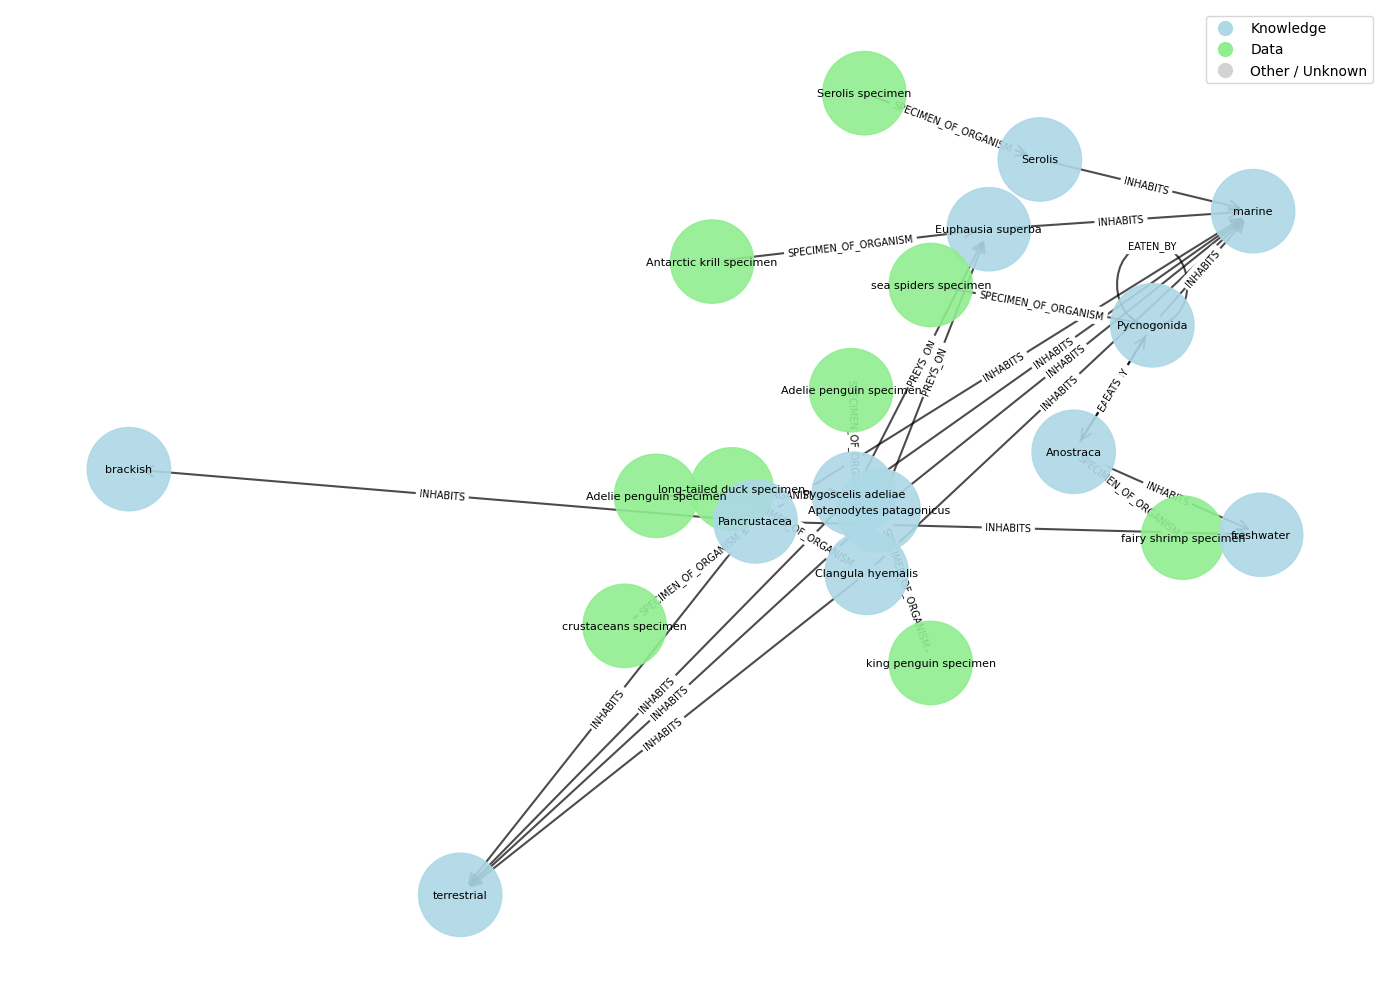

Graph image saved to: kg_graph.png


In [5]:
import networkx as nx
import matplotlib.pyplot as plt


# =========================
# 2. Read graph from Neo4j
# =========================
def load_neo4j_graph(graph, limit=300):
    """
    Load nodes and relationships from Neo4j into a NetworkX directed graph.

    This function assumes that each Neo4j node has:
        id
        node_type

    Example:
        node_type = "knowledge"
        node_type = "data"
    """

    G = nx.DiGraph()

    query = f"""
    MATCH (a)-[r]->(b)
    RETURN
        a.id AS source_id,
        coalesce(a.name, a.scientific_name, a.id) AS source_label,
        a.node_type AS source_type,
        type(r) AS relation_type,
        b.id AS target_id,
        coalesce(b.name, b.scientific_name, b.id) AS target_label,
        b.node_type AS target_type
    LIMIT {limit}
    """

    result = graph.run(query)

    for row in result:
        source_id = row["source_id"]
        target_id = row["target_id"]

        if source_id is None or target_id is None:
            continue

        source_type = row["source_type"]
        target_type = row["target_type"]

        if isinstance(source_type, str):
            source_type = source_type.strip().lower()

        if isinstance(target_type, str):
            target_type = target_type.strip().lower()

        G.add_node(
            source_id,
            label=row["source_label"],
            node_type=source_type,
        )

        G.add_node(
            target_id,
            label=row["target_label"],
            node_type=target_type,
        )

        G.add_edge(
            source_id,
            target_id,
            relation=row["relation_type"],
        )

    return G


# =========================
# 3. Draw graph
# =========================
def draw_graph(G, output_file="kg_graph.png", figsize=(14, 10)):
    """
    Draw a NetworkX graph and save it as an image.

    Node colors:
        knowledge -> lightblue
        data      -> lightgreen
        others    -> lightgray
    """

    from matplotlib.lines import Line2D

    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")

    # Check node_type distribution
    node_type_counts = {}

    for node, data in G.nodes(data=True):
        node_type = data.get("node_type")

        if node_type is None:
            node_type = "unknown"

        node_type = str(node_type).strip().lower()

        node_type_counts[node_type] = node_type_counts.get(node_type, 0) + 1

    print(f"Node type counts: {node_type_counts}")

    plt.figure(figsize=figsize)

    pos = nx.spring_layout(
        G,
        seed=42,
        k=0.8,
        iterations=100,
    )

    # =========================
    # Labels
    # =========================
    node_labels = {
        node: data.get("label", node)
        for node, data in G.nodes(data=True)
    }

    edge_labels = {
        (u, v): data.get("relation", "")
        for u, v, data in G.edges(data=True)
    }

    # =========================
    # Node colors
    # =========================
    node_colors = []

    for node, data in G.nodes(data=True):
        node_type = data.get("node_type")

        if node_type is None:
            node_type = ""

        node_type = str(node_type).strip().lower()

        if node_type == "knowledge":
            node_colors.append("lightblue")

        elif node_type == "data":
            node_colors.append("lightgreen")

        else:
            node_colors.append("lightgray")

    # =========================
    # Draw nodes
    # =========================
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=3600,
        node_color=node_colors,
        alpha=0.9,
    )

    # =========================
    # Draw edges
    # =========================
    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowstyle="->",
        arrowsize=18,
        width=1.5,
        alpha=0.7,
    )

    # =========================
    # Draw node labels
    # =========================
    nx.draw_networkx_labels(
        G,
        pos,
        labels=node_labels,
        font_size=8,
    )

    # =========================
    # Draw edge labels
    # =========================
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=7,
    )

    # =========================
    # Legend
    # =========================
    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Knowledge",
            markerfacecolor="lightblue",
            markersize=12,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Data",
            markerfacecolor="lightgreen",
            markersize=12,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Other / Unknown",
            markerfacecolor="lightgray",
            markersize=12,
        ),
    ]

    plt.legend(
        handles=legend_elements,
        loc="upper right",
    )

    plt.axis("off")
    plt.tight_layout()

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Graph image saved to: {output_file}")


# =========================
# 4. Run
# =========================
G = load_neo4j_graph(
    graph,
    limit=300,
)

draw_graph(
    G,
    output_file="kg_graph.png",
)